In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
# -------------------------------------------------------
# STEP 1 - Load the dataset
# -------------------------------------------------------

df = pd.read_csv("cybersecurity_attacks.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)




Shape: (40000, 25)

Columns: ['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']

First 5 rows:
             Timestamp Source IP Address Destination IP Address  Source Port  \
0  2023-05-30 06:33:58     103.216.15.12           84.9.164.252        31225   
1  2020-08-26 07:08:30    78.199.217.198         66.191.137.154        17245   
2  2022-11-13 08:23:25      63.79.210.48          198.219.82.17        16811   
3  2023-07-02 10:38:46     163.42.196.10        101.228.192.255        20018   
4  2023-07-16 13:11:07     71.166.185.76        189.243.174.238         6131   

   Destination Port Pro

In [5]:
# -------------------------------------------------------
# STEP 2 - Check Missing Values
# -------------------------------------------------------

print("\nMissing values in each column:")
print(df.isnull().sum())

# Fill missing values with meaningful defaults
df['Malware Indicators'] = df['Malware Indicators'].fillna('Unknown')
df['Alerts/Warnings'] = df['Alerts/Warnings'].fillna('No Alert')
df['Proxy Information'] = df['Proxy Information'].fillna('Unknown')
df['Firewall Logs'] = df['Firewall Logs'].fillna('No Log')
df['IDS/IPS Alerts'] = df['IDS/IPS Alerts'].fillna('No Alert')

print("\nMissing values after filling:")
print(df.isnull().sum())



Missing values in each column:
Timestamp                     0
Source IP Address             0
Destination IP Address        0
Source Port                   0
Destination Port              0
Protocol                      0
Packet Length                 0
Packet Type                   0
Traffic Type                  0
Payload Data                  0
Malware Indicators        20000
Anomaly Scores                0
Alerts/Warnings           20067
Attack Type                   0
Attack Signature              0
Action Taken                  0
Severity Level                0
User Information              0
Device Information            0
Network Segment               0
Geo-location Data             0
Proxy Information         19851
Firewall Logs             19961
IDS/IPS Alerts            20050
Log Source                    0
dtype: int64

Missing values after filling:
Timestamp                 0
Source IP Address         0
Destination IP Address    0
Source Port               0
Destination 

In [6]:
# -------------------------------------------------------
# STEP 3 - Summary Statistics
# -------------------------------------------------------

print("\nSummary Statistics:")
print(df[['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']].describe())

print("\nMean Anomaly Score:", round(df['Anomaly Scores'].mean(), 2))
print("Median Anomaly Score:", round(df['Anomaly Scores'].median(), 2))
print("Std Dev:", round(df['Anomaly Scores'].std(), 2))
print("Skewness:", round(df['Anomaly Scores'].skew(), 4))



Summary Statistics:
        Source Port  Destination Port  Packet Length  Anomaly Scores
count  40000.000000      40000.000000   40000.000000    40000.000000
mean   32970.356450      33150.868650     781.452725       50.113473
std    18560.425604      18574.668842     416.044192       28.853598
min     1027.000000       1024.000000      64.000000        0.000000
25%    16850.750000      17094.750000     420.000000       25.150000
50%    32856.000000      33004.500000     782.000000       50.345000
75%    48928.250000      49287.000000    1143.000000       75.030000
max    65530.000000      65535.000000    1500.000000      100.000000

Mean Anomaly Score: 50.11
Median Anomaly Score: 50.34
Std Dev: 28.85
Skewness: -0.0112


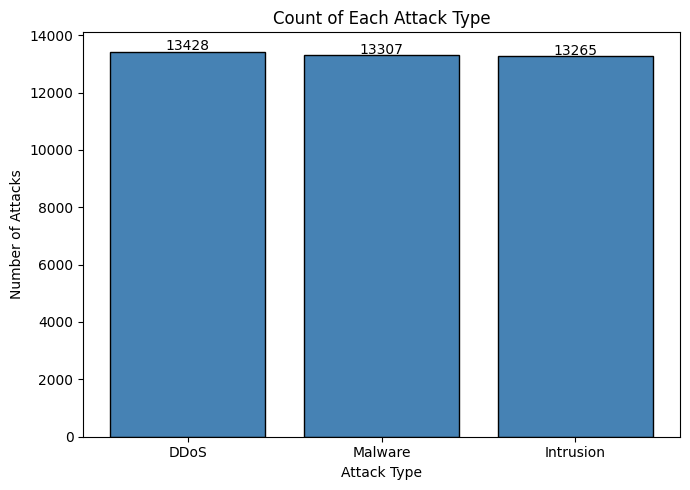

In [14]:
# -------------------------------------------------------
# OBJECTIVE 1 - Bar Chart: Count of Each Attack Type
# -------------------------------------------------------

attack_counts = df['Attack Type'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(attack_counts.index, attack_counts.values, color='steelblue', edgecolor='black')
plt.title('Count of Each Attack Type')
plt.xlabel('Attack Type')
plt.ylabel('Number of Attacks')
for i, v in enumerate(attack_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('graph1_attack_types.png', dpi=150)
#plt.close()
#print("Saved: graph1_attack_types.png")


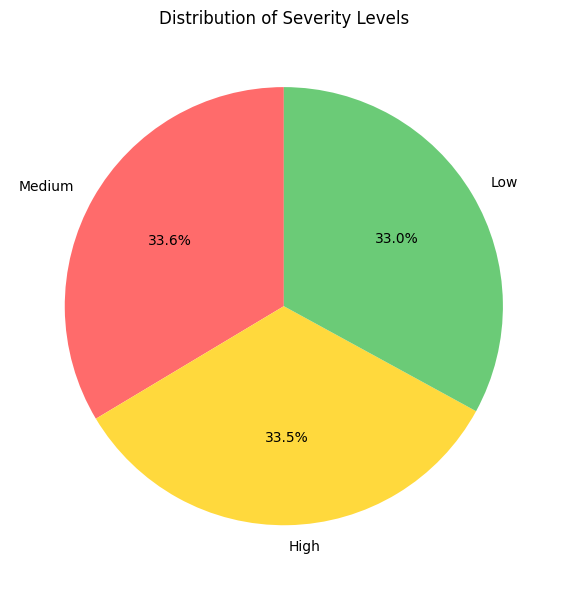

In [15]:
# -------------------------------------------------------
# OBJECTIVE 2 - Pie Chart: Severity Level Distribution
# -------------------------------------------------------

severity_counts = df['Severity Level'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(severity_counts.values, labels=severity_counts.index,
        autopct='%1.1f%%', colors=['#ff6b6b', '#ffd93d', '#6bcb77'], startangle=90)
plt.title('Distribution of Severity Levels')
plt.tight_layout()
plt.savefig('graph2_severity_pie.png', dpi=150)


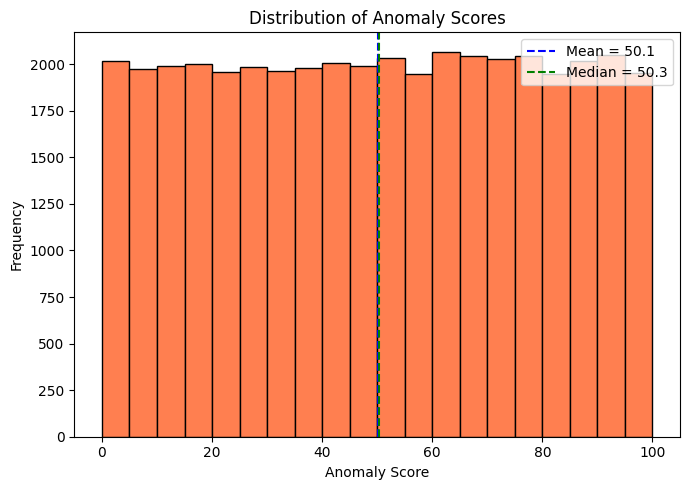

In [16]:
# -------------------------------------------------------
# OBJECTIVE 3 - Histogram: Anomaly Score Distribution
# -------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.hist(df['Anomaly Scores'], bins=20, color='coral', edgecolor='black')
plt.axvline(df['Anomaly Scores'].mean(), color='blue', linestyle='--',
            label=f"Mean = {df['Anomaly Scores'].mean():.1f}")
plt.axvline(df['Anomaly Scores'].median(), color='green', linestyle='--',
            label=f"Median = {df['Anomaly Scores'].median():.1f}")
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('graph3_anomaly_histogram.png', dpi=150)


<Figure size 800x500 with 0 Axes>

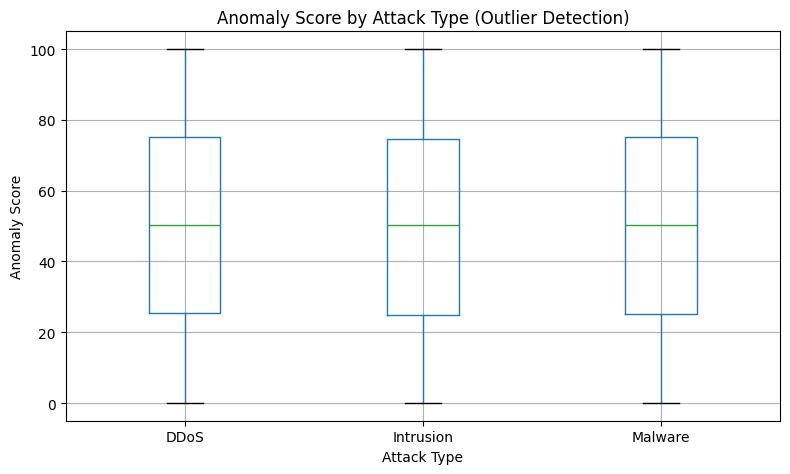

In [18]:
# -------------------------------------------------------
# OBJECTIVE 4 - Box Plot: Anomaly Score by Attack Type
# -------------------------------------------------------

plt.figure(figsize=(8, 5))
df.boxplot(column='Anomaly Scores', by='Attack Type', figsize=(8, 5))
plt.suptitle('')
plt.title('Anomaly Score by Attack Type (Outlier Detection)')
plt.xlabel('Attack Type')
plt.ylabel('Anomaly Score')
plt.tight_layout()
plt.savefig('graph4_boxplot_anomaly.png', dpi=150)

Q1 = df['Anomaly Scores'].quantile(0.25)
Q3 = df['Anomaly Scores'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Anomaly Scores'] < Q1 - 1.5 * IQR) | (df['Anomaly Scores'] > Q3 + 1.5 * IQR)]


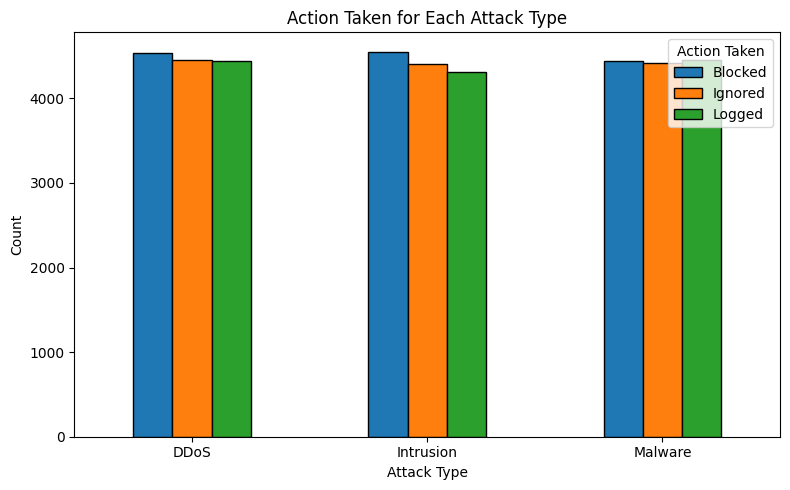

In [19]:
# -------------------------------------------------------
# OBJECTIVE 5 - Bar Chart: Action Taken vs Attack Type
# -------------------------------------------------------

action_attack = df.groupby(['Attack Type', 'Action Taken']).size().unstack()
action_attack.plot(kind='bar', figsize=(8, 5), edgecolor='black')
plt.title('Action Taken for Each Attack Type')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Action Taken')
plt.tight_layout()
plt.savefig('graph5_action_vs_attack.png', dpi=150)


In [12]:
# -------------------------------------------------------
# OBJECTIVE 6 - Hypothesis Testing: t-test
# -------------------------------------------------------

ddos_scores = df[df['Attack Type'] == 'DDoS']['Anomaly Scores']
malware_scores = df[df['Attack Type'] == 'Malware']['Anomaly Scores']

t_stat, p_value = stats.ttest_ind(ddos_scores, malware_scores)

print("\n--- t-test: DDoS vs Malware Anomaly Scores ---")
print(f"DDoS Mean: {ddos_scores.mean():.2f}")
print(f"Malware Mean: {malware_scores.mean():.2f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Reject H0 - Significant difference between DDoS and Malware anomaly scores")
else:
    print("Result: Accept H0 - No significant difference found")



--- t-test: DDoS vs Malware Anomaly Scores ---
DDoS Mean: 50.24
Malware Mean: 50.13
t-statistic: 0.3094
p-value: 0.757027
Result: Accept H0 - No significant difference found


In [13]:
# -------------------------------------------------------
# OBJECTIVE 7 (ML) - Random Forest: Predict Severity Level
# -------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

le_at = LabelEncoder()
le_pr = LabelEncoder()
le_sv = LabelEncoder()

df['Attack_enc'] = le_at.fit_transform(df['Attack Type'])
df['Protocol_enc'] = le_pr.fit_transform(df['Protocol'])
df['Severity_enc'] = le_sv.fit_transform(df['Severity Level'])

X = df[['Attack_enc', 'Protocol_enc', 'Packet Length', 'Anomaly Scores', 'Source Port', 'Destination Port']]
y = df['Severity_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n--- Random Forest Classifier Results ---")
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_sv.classes_, yticklabels=le_sv.classes_)
plt.title(f'Random Forest - Confusion Matrix (Accuracy: {acc:.2%})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('graph6_confusion_matrix.png', dpi=150)
plt.close()
print("Saved: graph6_confusion_matrix.png")

print("\nAll done!")



--- Random Forest Classifier Results ---
Accuracy: 0.3260
Saved: graph6_confusion_matrix.png

All done!
